# ALM — MAD Audio Encoder Training (Single-Label)

This notebook trains the **first single-label MAD audio encoder**.

- Dataset: MAD (`data/processed_mad/`)
- Task: single-label classification, **7 classes** (numeric labels `0`–`6`)
- Audio duration: **10 seconds** (MAD-specific — different from the original 5-second ALM configuration)
- Architecture: `MADAudioEncoder` from `utils/audio_mad_encoder.py`

This notebook is **self-contained** and can be run end-to-end from a fresh kernel, provided the
project structure described in `README.md` exists (`data/processed_mad/metadata.csv` and
`data/processed_mad/audio/`).

> **Not covered here:** multi-label training, `MultiLabelAudioEncoder`, `BCEWithLogitsLoss`, sigmoid
> activations, multi-hot labels, or per-class thresholds. Those belong to the separate multi-label
> experiment (`alm_audio_encoder_multilabel.ipynb`).


## 1. Imports & Setup

In [1]:
import os
import time
import random
import warnings
from pathlib import Path
import sys

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import librosa
import librosa.display
import soundfile as sf

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

print("Imports OK")

Imports OK


## 2. Reproducibility & Device

In [2]:
# ── Reproducibility ────────────────────────────────────────────────────
SEED = 42

def set_seed(seed: int = SEED) -> None:
    """Seed all relevant RNGs for reproducible results."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# ── Device ──────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("ALM — MAD Audio Encoder Training")
print("=" * 60)
print(f"Device        : {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
    print(f"CUDA version  : {torch.version.cuda}")
print("=" * 60)

ALM — MAD Audio Encoder Training
Device        : cuda
CUDA available: True
GPU           : NVIDIA GeForce RTX 4060 Laptop GPU
CUDA version  : 12.1


## 3. Configuration

**Important:** MAD clips range from ~1–10 seconds, unlike the original 5-second ALM
configuration. This experiment intentionally uses `DURATION = 10.0` so that no MAD clip
loses temporal information through trimming.


In [3]:
class Config:
    """Central configuration for the MAD single-label encoder training run."""

    SAMPLE_RATE: int = 16000
    DURATION: float = 10.0
    NUM_SAMPLES: int = 160000

    N_MELS: int = 128
    N_FFT: int = 1024
    HOP_LENGTH: int = 512

    EMBED_DIM: int = 512
    NUM_CLASSES: int = 7
    DROPOUT: float = 0.3

    BATCH_SIZE: int = 16
    EPOCHS: int = 50
    LEARNING_RATE: float = 3e-4
    WEIGHT_DECAY: float = 1e-4
    VAL_SPLIT: float = 0.20
    PATIENCE: int = 8
    NUM_WORKERS: int = 0

    AMP: bool = torch.cuda.is_available()

    SEED: int = SEED


CFG = Config()

assert CFG.NUM_SAMPLES == int(CFG.SAMPLE_RATE * CFG.DURATION), "NUM_SAMPLES must match SAMPLE_RATE * DURATION"

print("=" * 60)
print("Configuration")
print("=" * 60)
for key, value in vars(Config).items():
    if not key.startswith("_"):
        print(f"{key:15s}: {value}")
print("=" * 60)

Configuration
SAMPLE_RATE    : 16000
DURATION       : 10.0
NUM_SAMPLES    : 160000
N_MELS         : 128
N_FFT          : 1024
HOP_LENGTH     : 512
EMBED_DIM      : 512
NUM_CLASSES    : 7
DROPOUT        : 0.3
BATCH_SIZE     : 16
EPOCHS         : 50
LEARNING_RATE  : 0.0003
WEIGHT_DECAY   : 0.0001
VAL_SPLIT      : 0.2
PATIENCE       : 8
NUM_WORKERS    : 0
AMP            : True
SEED           : 42


## 4. Project Paths

In [4]:
# ── Project root discovery ──────────────────────────────────────────────
# This notebook lives at <PROJECT_ROOT>/scripts/alm_mad_encoder_training.ipynb.
# We resolve PROJECT_ROOT robustly from the notebook's own working directory
# rather than assuming any absolute path.
_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    sys.path.insert(0, str(PROJECT_ROOT.parent))

DATA_DIR = PROJECT_ROOT / "data" / "processed_mad"
AUDIO_DIR = DATA_DIR / "audio"
METADATA_FILE = DATA_DIR / "metadata.csv"

MODEL_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Project Paths")
print("=" * 60)
print(f"Project Root    : {PROJECT_ROOT}")
print(f"Metadata        : {METADATA_FILE}")
print(f"Audio Directory : {AUDIO_DIR}")
print(f"Model Directory : {MODEL_DIR}")
print(f"Figures Directory: {FIGURES_DIR}")
print("=" * 60)

if not METADATA_FILE.exists():
    raise FileNotFoundError(
        f"MAD metadata file not found at: {METADATA_FILE}\n"
        "Expected the MAD dataset to already be preprocessed under "
        "'data/processed_mad/' (metadata.csv + audio/)."
    )

Project Paths
Project Root    : c:\Users\PRAYAG\Desktop\ALM\alm
Metadata        : c:\Users\PRAYAG\Desktop\ALM\alm\data\processed_mad\metadata.csv
Audio Directory : c:\Users\PRAYAG\Desktop\ALM\alm\data\processed_mad\audio
Model Directory : c:\Users\PRAYAG\Desktop\ALM\alm\models
Figures Directory: c:\Users\PRAYAG\Desktop\ALM\alm\outputs\figures


## 5. Load and Inspect MAD Metadata

In [5]:
metadata = pd.read_csv(METADATA_FILE)

print("=" * 60)
print("MAD Metadata — Raw Inspection")
print("=" * 60)
print(f"Shape   : {metadata.shape}")
print(f"Columns : {list(metadata.columns)}")
print("-" * 60)
print(metadata.head())
print("=" * 60)

MAD Metadata — Raw Inspection
Shape   : (7466, 8)
Columns : ['id', 'file', 'label', 'label_name', 'split', 'duration_original', 'duration_processed', 'source_file']
------------------------------------------------------------
   id                file  label label_name     split  duration_original  \
0   1  alm_mad_000001.wav      3   Shelling  training                2.0   
1   2  alm_mad_000002.wav      3   Shelling  training                3.0   
2   3  alm_mad_000003.wav      3   Shelling  training                2.0   
3   4  alm_mad_000004.wav      3   Shelling  training                3.0   
4   5  alm_mad_000005.wav      3   Shelling  training                3.0   

   duration_processed         source_file  
0                10.0  training/398/0.wav  
1                10.0  training/398/1.wav  
2                10.0  training/398/2.wav  
3                10.0  training/398/3.wav  
4                10.0  training/398/4.wav  


In [6]:
# ── Discover the relevant columns dynamically ───────────────────────────
# We inspect the actual CSV rather than assuming specific column names.

def _find_column(columns, candidates):
    """Return the first column name (case-insensitive) matching any candidate."""
    lower_map = {c.lower(): c for c in columns}
    for candidate in candidates:
        if candidate in lower_map:
            return lower_map[candidate]
    return None


columns = list(metadata.columns)

PATH_COL = _find_column(columns, ["path", "filepath", "file_path", "audio_path", "filename", "file"])
LABEL_COL = _find_column(columns, ["label", "class", "class_id", "target", "y"])
SPLIT_COL = _find_column(columns, ["split", "subset", "set", "partition"])

if PATH_COL is None or LABEL_COL is None:
    raise ValueError(
        f"Could not identify required columns in metadata.csv. "
        f"Found columns: {columns}. Expected an audio path column and a numeric label column."
    )

print("Discovered columns:")
print(f"  Audio path column : '{PATH_COL}'")
print(f"  Label column      : '{LABEL_COL}'")
print(f"  Split column      : '{SPLIT_COL}'" if SPLIT_COL else "  Split column      : NOT FOUND")

Discovered columns:
  Audio path column : 'file'
  Label column      : 'label'
  Split column      : 'split'


In [7]:
# ── Dataset summary ──────────────────────────────────────────────────────
labels_sorted = sorted(metadata[LABEL_COL].unique().tolist())
num_classes_found = len(labels_sorted)

if num_classes_found != CFG.NUM_CLASSES:
    print(
        f"⚠ WARNING: metadata.csv contains {num_classes_found} unique labels "
        f"({labels_sorted}), but CFG.NUM_CLASSES = {CFG.NUM_CLASSES}."
    )

print("=" * 60)
print("MAD Dataset")
print("=" * 60)
print(f"Total samples : {len(metadata)}")
print(f"Classes       : {num_classes_found}")
print(f"Labels        : {labels_sorted}")
if SPLIT_COL:
    print(f"Splits found  : {sorted(metadata[SPLIT_COL].unique().tolist())}")
print("=" * 60)

class_distribution = metadata[LABEL_COL].value_counts().sort_index()
class_distribution.index = [f"Class {i}" for i in class_distribution.index]
print("\nClass distribution:")
print(class_distribution.to_string())

MAD Dataset
Total samples : 7466
Classes       : 7
Labels        : [0, 1, 2, 3, 4, 5, 6]
Splits found  : ['test', 'training']

Class distribution:
Class 0     981
Class 1    1573
Class 2     877
Class 3     987
Class 4    1032
Class 5    1025
Class 6     991


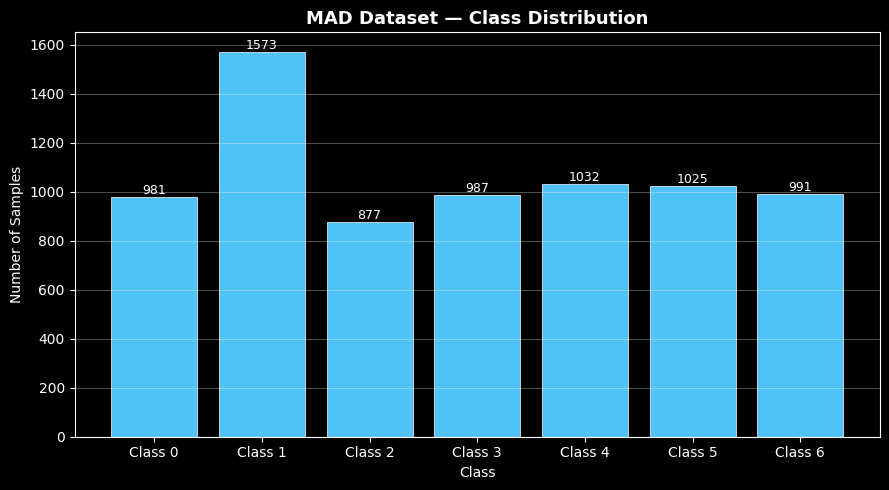

Saved figure → c:\Users\PRAYAG\Desktop\ALM\alm\outputs\figures\mad_training_class_distribution.png


In [8]:
# ── Class distribution figure ────────────────────────────────────────────
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    class_distribution.index,
    class_distribution.values,
    color="#4FC3F7",
    edgecolor="white",
    linewidth=0.5,
)
ax.set_title("MAD Dataset — Class Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Samples")
ax.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, class_distribution.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(value),
            ha="center", va="bottom", fontsize=9, color="white")

fig.tight_layout()
class_dist_path = FIGURES_DIR / "mad_training_class_distribution.png"
fig.savefig(class_dist_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()

print(f"Saved figure → {class_dist_path}")

## 6. Train / Validation / Test Split

MAD already provides an official training/test split. The **official test set is kept
completely untouched** until final evaluation (Section 18). Only the official training
partition is split into training/validation (80/20, stratified by label).


In [9]:
if SPLIT_COL is not None:
    split_values = metadata[SPLIT_COL].astype(str).str.lower()
    train_mask = split_values.str.contains("train")
    test_mask = split_values.str.contains("test")

    official_train_df = metadata[train_mask].reset_index(drop=True)
    official_test_df = metadata[test_mask].reset_index(drop=True)

    if len(official_train_df) == 0 or len(official_test_df) == 0:
        raise ValueError(
            f"Split column '{SPLIT_COL}' was found but training/test partitions could not be "
            f"identified from its values: {sorted(split_values.unique().tolist())}"
        )
else:
    # No explicit split column: derive the split from the audio path, which is expected
    # to contain 'training' or 'test' as described in the project structure.
    path_values = metadata[PATH_COL].astype(str).str.lower()
    train_mask = path_values.str.contains("train")
    test_mask = path_values.str.contains("test")

    official_train_df = metadata[train_mask].reset_index(drop=True)
    official_test_df = metadata[test_mask].reset_index(drop=True)

    if len(official_train_df) == 0 or len(official_test_df) == 0:
        raise ValueError(
            "Could not identify a training/test split from metadata.csv. Neither a split "
            "column nor path-based 'training'/'test' markers were found."
        )

print(f"Original training samples : {len(official_train_df)}")
print(f"Official test samples     : {len(official_test_df)}")

Original training samples : 6429
Official test samples     : 1037


In [10]:
# ── Stratified train/validation split (test set is NEVER touched here) ──
try:
    train_df, val_df = train_test_split(
        official_train_df,
        test_size=CFG.VAL_SPLIT,
        random_state=CFG.SEED,
        stratify=official_train_df[LABEL_COL],
    )
except ValueError as exc:
    raise ValueError(
        "Stratified train/validation split failed. This usually means a class has too few "
        f"samples to be stratified. Original error: {exc}"
    ) from exc

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = official_test_df.reset_index(drop=True)

print("=" * 60)
print("Train / Validation / Test Split")
print("=" * 60)
print(f"Training samples   : {len(train_df)}")
print(f"Validation samples : {len(val_df)}")
print(f"Test samples        : {len(test_df)}")
print("=" * 60)

for name, split_df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    dist = split_df[LABEL_COL].value_counts().sort_index()
    print(f"\n{name} class distribution:")
    print(dist.to_string())

missing_train = set(labels_sorted) - set(train_df[LABEL_COL].unique())
missing_val = set(labels_sorted) - set(val_df[LABEL_COL].unique())
if missing_train or missing_val:
    raise ValueError(
        f"Stratified split produced missing classes. Missing in train: {missing_train}, "
        f"missing in val: {missing_val}."
    )

Train / Validation / Test Split
Training samples   : 5143
Validation samples : 1286
Test samples        : 1037

Train class distribution:
label
0     619
1    1034
2     619
3     706
4     728
5     747
6     690

Validation class distribution:
label
0    155
1    259
2    154
3    177
4    182
5    187
6    172

Test class distribution:
label
0    207
1    280
2    104
3    104
4    122
5     91
6    129


## 7. Audio Loading & Preprocessing

MAD clips range from ~1–10 seconds, with no clip exceeding 10 seconds. To preserve all
temporal information:

- clips **shorter** than 10s are zero-padded at the end
- clips **exactly** 10s are left unchanged
- clips **longer** than 10s should never occur — this raises an explicit error instead of
  silently trimming audio.


In [11]:
def load_audio(filepath: Path) -> np.ndarray:
    """
    Load a MAD audio file, convert to mono, resample to CFG.SAMPLE_RATE, and
    zero-pad to exactly CFG.NUM_SAMPLES.

    10 seconds is intentionally used for MAD so that all valid MAD clips can be
    represented without temporal information loss.

    Args:
        filepath: path to the audio file.

    Returns:
        1-D float32 numpy array of length CFG.NUM_SAMPLES.

    Raises:
        FileNotFoundError: if the audio file does not exist.
        ValueError: if the loaded audio exceeds CFG.NUM_SAMPLES (the 10-second limit).
    """
    if not filepath.exists():
        raise FileNotFoundError(f"Audio file not found: {filepath}")

    y, _ = librosa.load(filepath, sr=CFG.SAMPLE_RATE, mono=True)
    y = y.astype(np.float32)

    if len(y) > CFG.NUM_SAMPLES:
        raise ValueError(
            f"Audio sample exceeds the configured 10-second limit "
            f"({len(y)} samples > {CFG.NUM_SAMPLES} samples) for file: {filepath}. "
            "This pipeline intentionally does not trim audio to avoid losing information; "
            "please check this file, as no MAD clip is expected to exceed 10 seconds."
        )

    if len(y) < CFG.NUM_SAMPLES:
        pad_width = CFG.NUM_SAMPLES - len(y)
        y = np.pad(y, (0, pad_width), mode="constant")

    return y


def compute_melspec(y: np.ndarray) -> np.ndarray:
    """
    Compute a log-Mel spectrogram from a waveform.

    Args:
        y: 1-D float32 waveform at CFG.SAMPLE_RATE.

    Returns:
        (N_MELS, ~313) float32 log-Mel spectrogram in dB.
    """
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=CFG.SAMPLE_RATE,
        n_fft=CFG.N_FFT,
        hop_length=CFG.HOP_LENGTH,
        n_mels=CFG.N_MELS,
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)
    return log_mel.astype(np.float32)


def preprocess_audio(filepath: Path) -> np.ndarray:
    """Load, pad to 10 seconds, and compute the log-Mel spectrogram for a file."""
    y = load_audio(filepath)
    return compute_melspec(y)


print("Audio preprocessing functions ready.")
print(f"Target sample rate : {CFG.SAMPLE_RATE} Hz")
print(f"Target duration    : {CFG.DURATION} s ({CFG.NUM_SAMPLES} samples)")

Audio preprocessing functions ready.
Target sample rate : 16000 Hz
Target duration    : 10.0 s (160000 samples)


In [12]:
# ── Quick preprocessing sanity check on a real file ─────────────────────
_sample_row = train_df.iloc[0]
_sample_path = AUDIO_DIR / str(_sample_row[PATH_COL])

_mel_sample = preprocess_audio(_sample_path)
print(f"Sample file      : {_sample_path.name}")
print(f"Mel spectrogram  : {_mel_sample.shape}  (expected ~({CFG.N_MELS}, 313))")

c:\Users\PRAYAG\Desktop\ALM\alm\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sample file      : alm_mad_002812.wav
Mel spectrogram  : (128, 313)  (expected ~(128, 313))


## 8. Dataset Class

In [13]:
class MADAudioDataset(Dataset):
    """
    PyTorch Dataset for single-label MAD audio classification.

    Audio is loaded and processed lazily in __getitem__ to avoid loading the
    entire dataset into memory.
    """

    def __init__(self, dataframe: pd.DataFrame, audio_dir: Path, path_col: str, label_col: str):
        self.df = dataframe.reset_index(drop=True)
        self.audio_dir = audio_dir
        self.path_col = path_col
        self.label_col = label_col

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        filepath = self.audio_dir / str(row[self.path_col])

        if not filepath.exists():
            raise FileNotFoundError(
                f"Expected MAD audio file not found at: {filepath} (row index {idx})"
            )

        mel = preprocess_audio(filepath)          # (128, ~313)
        mel_tensor = torch.from_numpy(mel).unsqueeze(0)  # (1, 128, ~313)

        label = torch.tensor(int(row[self.label_col]), dtype=torch.long)

        return {"mel": mel_tensor, "label": label}


print("MADAudioDataset ready.")

MADAudioDataset ready.


## 9. DataLoaders

In [14]:
train_dataset = MADAudioDataset(train_df, AUDIO_DIR, PATH_COL, LABEL_COL)
val_dataset = MADAudioDataset(val_df, AUDIO_DIR, PATH_COL, LABEL_COL)
test_dataset = MADAudioDataset(test_df, AUDIO_DIR, PATH_COL, LABEL_COL)

_pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True,
    num_workers=CFG.NUM_WORKERS, pin_memory=_pin_memory,
)
val_loader = DataLoader(
    val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False,
    num_workers=CFG.NUM_WORKERS, pin_memory=_pin_memory,
)
test_loader = DataLoader(
    test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False,
    num_workers=CFG.NUM_WORKERS, pin_memory=_pin_memory,
)

print(f"Train batches      : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")
print(f"Test batches       : {len(test_loader)}")
print(f"Batch size         : {CFG.BATCH_SIZE}")

Train batches      : 322
Validation batches : 81
Test batches       : 65
Batch size         : 16


In [15]:
# ── Single batch sanity check ────────────────────────────────────────────
_batch = next(iter(train_loader))
print(f"Mel batch shape  : {_batch['mel'].shape}")
print(f"Label batch shape: {_batch['label'].shape}")
print(f"Label values     : {_batch['label'].tolist()}")

Mel batch shape  : torch.Size([16, 1, 128, 313])
Label batch shape: torch.Size([16])
Label values     : [1, 3, 5, 6, 1, 1, 4, 2, 6, 6, 1, 2, 2, 3, 6, 6]


## 10. Model Creation

In [16]:
from utils import MADAudioEncoder

model = MADAudioEncoder(
    embed_dim=CFG.EMBED_DIM,
    num_classes=CFG.NUM_CLASSES,
    dropout=CFG.DROPOUT,
).to(device)

print("=" * 60)
print("MAD Audio Encoder")
print("=" * 60)
print("Architecture : CNN + Projection Head")
print(f"Embedding dim: {CFG.EMBED_DIM}")
print(f"Classes      : {CFG.NUM_CLASSES}")
print(f"Parameters   : {model.count_params():,}")
print(f"Device       : {device}")
print("=" * 60)

MAD Audio Encoder
Architecture : CNN + Projection Head
Embedding dim: 512
Classes      : 7
Parameters   : 5,899,367
Device       : cuda


In [17]:
# ── Forward-pass sanity check on a real batch ────────────────────────────
model.eval()
with torch.no_grad():
    _mel = _batch["mel"].to(device)
    _embedding = model.encode(_mel)
    _logits = model(_mel)

print(f"Input shape     : {tuple(_mel.shape)}")
print(f"Embedding shape : {tuple(_embedding.shape)}")
print(f"Logits shape    : {tuple(_logits.shape)}")

_norms = _embedding.norm(dim=-1)
print(f"Embedding norms : mean={_norms.mean().item():.4f}, "
      f"min={_norms.min().item():.4f}, max={_norms.max().item():.4f}")

Input shape     : (16, 1, 128, 313)
Embedding shape : (16, 512)
Logits shape    : (16, 7)
Embedding norms : mean=1.0000, min=1.0000, max=1.0000


## 11. Loss, Optimizer & Scheduler

This is a **single-label** classification problem: `nn.CrossEntropyLoss` operates on raw
logits and integer class targets. `BCEWithLogitsLoss` and sigmoid activations are not used
anywhere in this notebook.


In [18]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.LEARNING_RATE,
    weight_decay=CFG.WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.EPOCHS)

scaler = torch.amp.GradScaler("cuda", enabled=CFG.AMP)

print(f"Criterion : {criterion.__class__.__name__}")
print(f"Optimizer : {optimizer.__class__.__name__} (lr={CFG.LEARNING_RATE}, weight_decay={CFG.WEIGHT_DECAY})")
print(f"Scheduler : {scheduler.__class__.__name__} (T_max={CFG.EPOCHS})")
print(f"AMP       : {CFG.AMP}")

Criterion : CrossEntropyLoss
Optimizer : AdamW (lr=0.0003, weight_decay=0.0001)
Scheduler : CosineAnnealingLR (T_max=50)
AMP       : True


## 12. Training Functions

In [19]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device, epoch, total_epochs) -> tuple[float, float]:
    """Run one training epoch. Returns (avg_loss, accuracy)."""
    model.train()
    running_loss = 0.0
    running_correct = 0
    seen = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch}/{total_epochs}", leave=False)
    for batch in pbar:
        mel = batch["mel"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=CFG.AMP):
            logits = model(mel)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_correct += (logits.argmax(dim=-1) == labels).sum().item()
        seen += batch_size

        pbar.set_postfix(
            loss=f"{running_loss / seen:.4f}",
            acc=f"{running_correct / seen * 100:.2f}%",
            lr=f"{optimizer.param_groups[0]['lr']:.2e}",
        )

    return running_loss / seen, running_correct / seen


@torch.no_grad()
def evaluate(model, loader, criterion, device, desc: str = "Validation") -> tuple[float, float]:
    """Run evaluation over a loader. Returns (avg_loss, accuracy)."""
    model.eval()
    running_loss = 0.0
    running_correct = 0
    seen = 0

    pbar = tqdm(loader, desc=desc, leave=False)
    for batch in pbar:
        mel = batch["mel"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=CFG.AMP):
            logits = model(mel)
            loss = criterion(logits, labels)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_correct += (logits.argmax(dim=-1) == labels).sum().item()
        seen += batch_size

        pbar.set_postfix(
            loss=f"{running_loss / seen:.4f}",
            acc=f"{running_correct / seen * 100:.2f}%",
        )

    return running_loss / seen, running_correct / seen


print("Training and evaluation functions ready.")

Training and evaluation functions ready.


## 13. Training Loop

In [20]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "lr": [],
}

BEST_MODEL_PATH = MODEL_DIR / "alm_mad_audio_encoder_best.pth"
FINAL_MODEL_PATH = MODEL_DIR / "alm_mad_audio_encoder_final.pth"

_checkpoint_config = {
    "sample_rate": CFG.SAMPLE_RATE,
    "duration": CFG.DURATION,
    "num_samples": CFG.NUM_SAMPLES,
    "n_mels": CFG.N_MELS,
    "n_fft": CFG.N_FFT,
    "hop_length": CFG.HOP_LENGTH,
    "embed_dim": CFG.EMBED_DIM,
    "num_classes": CFG.NUM_CLASSES,
    "batch_size": CFG.BATCH_SIZE,
    "learning_rate": CFG.LEARNING_RATE,
    "weight_decay": CFG.WEIGHT_DECAY,
    "dropout": CFG.DROPOUT,
}

best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0

training_start_time = time.time()

for epoch in range(1, CFG.EPOCHS + 1):
    epoch_start = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, device, epoch, CFG.EPOCHS
    )
    val_loss, val_acc = evaluate(model, val_loader, criterion, device, desc=f"Validation {epoch}/{CFG.EPOCHS}")

    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    epoch_time = time.time() - epoch_start

    improved = val_loss < best_val_loss
    if improved:
        best_val_loss = val_loss
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "val_loss": val_loss,
            "val_acc": val_acc,
            "config": _checkpoint_config,
            "label_classes": labels_sorted,
            "dataset": "MAD",
            "single_label": True,
        }, BEST_MODEL_PATH)
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch:02d}/{CFG.EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc * 100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc * 100:.2f}% | "
        f"LR: {current_lr:.2e} | Time: {epoch_time:.1f}s"
        + ("  ✅ Best model saved" if improved else "")
    )
    if improved:
        print(f"  ✅ Best model saved → {BEST_MODEL_PATH}")

    if epochs_without_improvement >= CFG.PATIENCE:
        print(f"\n⏹ Early stopping triggered at epoch {epoch}")
        break

total_training_time = time.time() - training_start_time

print("\n" + "=" * 60)
print("Training Complete")
print("=" * 60)
print(f"Best epoch    : {best_epoch}")
print(f"Best val loss : {best_val_loss:.4f}")
print(f"Best val acc  : {history['val_acc'][best_epoch - 1] * 100:.2f}%")
print(f"Training time : {total_training_time / 60:.2f} min")
print(f"Best model    : {BEST_MODEL_PATH}")
print("=" * 60)

Epoch 01/50 | Train Loss: 1.3121 | Train Acc: 55.01% | Val Loss: 0.8888 | Val Acc: 76.44% | LR: 3.00e-04 | Time: 98.6s  ✅ Best model saved
  ✅ Best model saved → c:\Users\PRAYAG\Desktop\ALM\alm\models\alm_mad_audio_encoder_best.pth


Epoch 02/50 | Train Loss: 0.8452 | Train Acc: 73.93% | Val Loss: 0.8143 | Val Acc: 72.86% | LR: 2.99e-04 | Time: 45.1s  ✅ Best model saved
  ✅ Best model saved → c:\Users\PRAYAG\Desktop\ALM\alm\models\alm_mad_audio_encoder_best.pth


Epoch 03/50 | Train Loss: 0.6680 | Train Acc: 78.32% | Val Loss: 0.5551 | Val Acc: 84.99% | LR: 2.97e-04 | Time: 44.0s  ✅ Best model saved
  ✅ Best model saved → c:\Users\PRAYAG\Desktop\ALM\alm\models\alm_mad_audio_encoder_best.pth


Epoch 04/50 | Train Loss: 0.5543 | Train Acc: 81.64% | Val Loss: 0.6835 | Val Acc: 75.19% | LR: 2.95e-04 | Time: 44.0s


Epoch 05/50 | Train Loss: 0.4966 | Train Acc: 83.65% | Val Loss: 0.5885 | Val Acc: 80.09% | LR: 2.93e-04 | Time: 42.3s


...

Epoch 35/50 | Train Loss: 0.0498 | Train Acc: 98.70% | Val Loss: 0.2187 | Val Acc: 93.93% | LR: 6.18e-05 | Time: 42.6s


Epoch 36/50 | Train Loss: 0.0379 | Train Acc: 98.91% | Val Loss: 0.2079 | Val Acc: 94.32% | LR: 5.44e-05 | Time: 42.6s


Epoch 37/50 | Train Loss: 0.0339 | Train Acc: 99.14% | Val Loss: 0.2207 | Val Acc: 94.09% | LR: 4.73e-05 | Time: 41.2s


Epoch 38/50 | Train Loss: 0.0335 | Train Acc: 99.20% | Val Loss: 0.2121 | Val Acc: 94.25% | LR: 4.07e-05 | Time: 42.6s


Epoch 39/50 | Train Loss: 0.0323 | Train Acc: 99.09% | Val Loss: 0.2412 | Val Acc: 93.93% | LR: 3.44e-05 | Time: 41.7s

⏹ Early stopping triggered at epoch 39

Training Complete
Best epoch    : 31
Best val loss : 0.1892
Best val acc  : 94.63%
Training time : 28.70 min
Best model    : c:\Users\PRAYAG\Desktop\ALM\alm\models\alm_mad_audio_encoder_best.pth


## 14. Early Stopping

Early stopping is implemented directly inside the training loop above (Section 13), using
`PATIENCE = 8` consecutive epochs without validation-loss improvement. The cell below simply
reports the outcome for clarity.


In [21]:
print(f"Patience              : {CFG.PATIENCE}")
print(f"Epochs completed      : {len(history['train_loss'])}")
print(f"Early stopping fired  : {epochs_without_improvement >= CFG.PATIENCE}")

Patience              : 8
Epochs completed      : 39
Early stopping fired  : True


## 15. Save Final Model

In [22]:
torch.save({
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "scheduler_state": scheduler.state_dict(),
    "history": history,
    "config": _checkpoint_config,
    "label_classes": labels_sorted,
    "best_epoch": best_epoch,
    "dataset": "MAD",
    "single_label": True,
}, FINAL_MODEL_PATH)

print(f"✅ Final model saved → {FINAL_MODEL_PATH}")

print("\nFiles in models directory:")
for f in sorted(MODEL_DIR.glob("*.pth")):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  {f.name:45s} {size_mb:8.2f} MB")

✅ Final model saved → c:\Users\PRAYAG\Desktop\ALM\alm\models\alm_mad_audio_encoder_final.pth

Files in models directory:
  alm_audio_encoder_best.pth                       64.68 MB
  alm_audio_encoder_final.pth                      64.69 MB
  alm_mad_audio_encoder_best.pth                   67.58 MB
  alm_mad_audio_encoder_final.pth                  67.58 MB
  alm_multilabel_best.pth                          65.22 MB
  alm_multilabel_final.pth                         65.23 MB


## 16. Training Curves

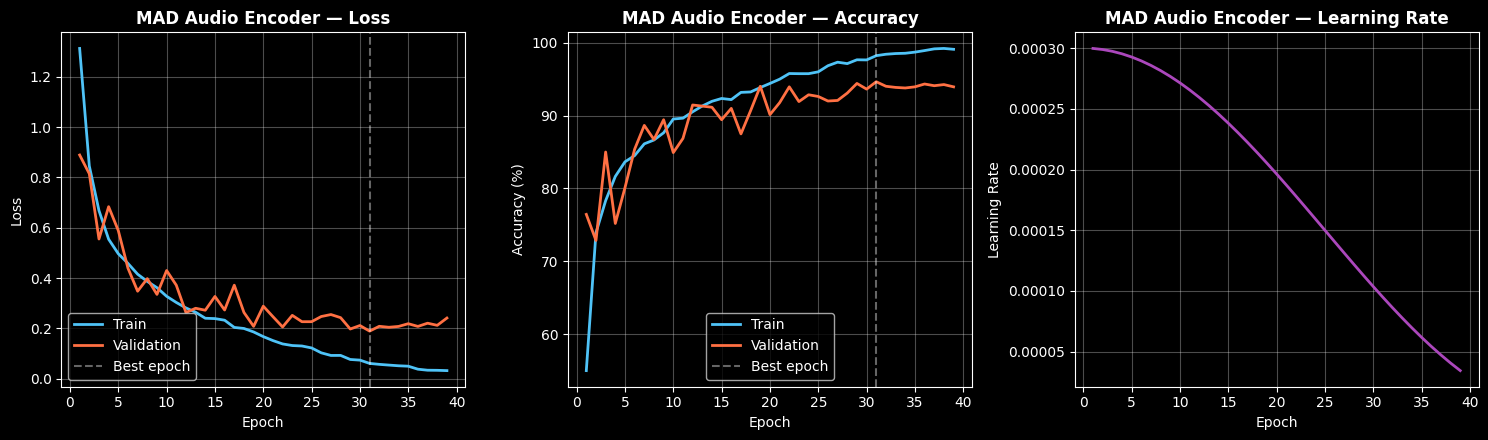

Saved figure → c:\Users\PRAYAG\Desktop\ALM\alm\outputs\figures\mad_encoder_training_curves.png


In [23]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig = plt.figure(figsize=(15, 4.5))
gs = gridspec.GridSpec(1, 3, figure=fig)

# Loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs_range, history["train_loss"], label="Train", color="#4FC3F7", linewidth=2)
ax1.plot(epochs_range, history["val_loss"], label="Validation", color="#FF7043", linewidth=2)
ax1.axvline(best_epoch, color="white", linestyle="--", alpha=0.4, label="Best epoch")
ax1.set_title("MAD Audio Encoder — Loss", fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(alpha=0.3)

# Accuracy
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs_range, [a * 100 for a in history["train_acc"]], label="Train", color="#4FC3F7", linewidth=2)
ax2.plot(epochs_range, [a * 100 for a in history["val_acc"]], label="Validation", color="#FF7043", linewidth=2)
ax2.axvline(best_epoch, color="white", linestyle="--", alpha=0.4, label="Best epoch")
ax2.set_title("MAD Audio Encoder — Accuracy", fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(alpha=0.3)

# Learning rate
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(epochs_range, history["lr"], color="#AB47BC", linewidth=2)
ax3.set_title("MAD Audio Encoder — Learning Rate", fontweight="bold")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Learning Rate")
ax3.grid(alpha=0.3)

fig.tight_layout()
curves_path = FIGURES_DIR / "mad_encoder_training_curves.png"
fig.savefig(curves_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()
print(f"Saved figure → {curves_path}")

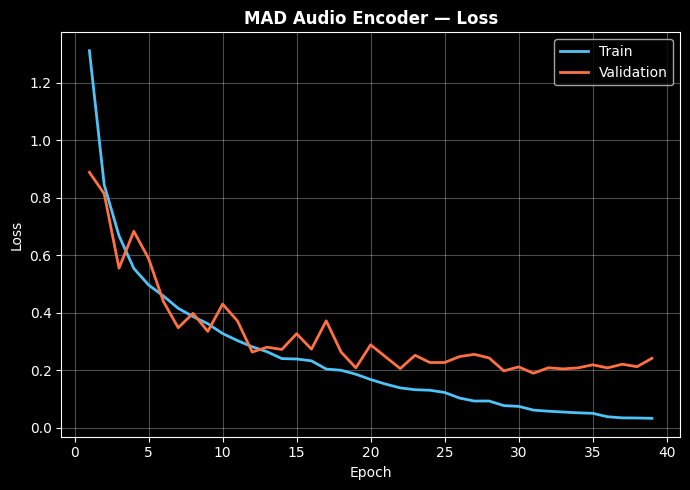

Saved figure → c:\Users\PRAYAG\Desktop\ALM\alm\outputs\figures\mad_encoder_loss.png


In [24]:
# Separate loss figure
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(epochs_range, history["train_loss"], label="Train", color="#4FC3F7", linewidth=2)
ax.plot(epochs_range, history["val_loss"], label="Validation", color="#FF7043", linewidth=2)
ax.set_title("MAD Audio Encoder — Loss", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
loss_path = FIGURES_DIR / "mad_encoder_loss.png"
fig.savefig(loss_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()
print(f"Saved figure → {loss_path}")

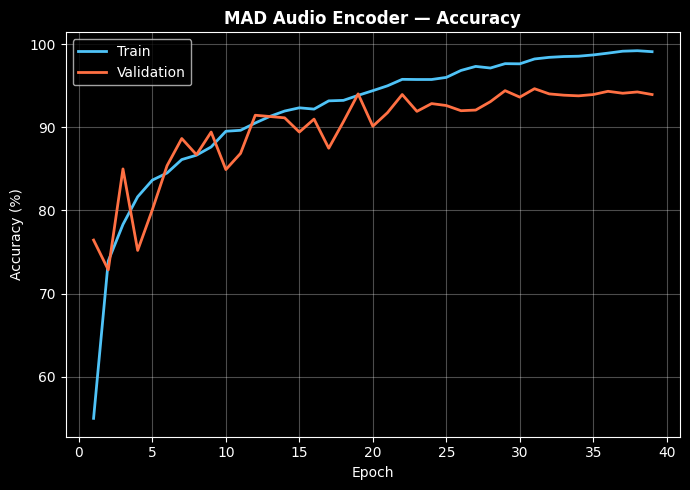

Saved figure → c:\Users\PRAYAG\Desktop\ALM\alm\outputs\figures\mad_encoder_accuracy.png


In [25]:
# Separate accuracy figure
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(epochs_range, [a * 100 for a in history["train_acc"]], label="Train", color="#4FC3F7", linewidth=2)
ax.plot(epochs_range, [a * 100 for a in history["val_acc"]], label="Validation", color="#FF7043", linewidth=2)
ax.set_title("MAD Audio Encoder — Accuracy", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
acc_path = FIGURES_DIR / "mad_encoder_accuracy.png"
fig.savefig(acc_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()
print(f"Saved figure → {acc_path}")

## 17. Load Best Model

In [26]:
best_checkpoint = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=False)

best_model = MADAudioEncoder(
    embed_dim=best_checkpoint["config"]["embed_dim"],
    num_classes=best_checkpoint["config"]["num_classes"],
    dropout=CFG.DROPOUT,
).to(device)
best_model.load_state_dict(best_checkpoint["model_state"])
best_model.eval()

print("✅ Loaded best MAD encoder")
print(f"Epoch              : {best_checkpoint['epoch']}")
print(f"Validation loss     : {best_checkpoint['val_loss']:.4f}")
print(f"Validation accuracy : {best_checkpoint['val_acc'] * 100:.2f}%")
print(f"Embedding dimension : {best_checkpoint['config']['embed_dim']}")
print(f"Number of classes   : {best_checkpoint['config']['num_classes']}")

✅ Loaded best MAD encoder
Epoch              : 31
Validation loss     : 0.1892
Validation accuracy : 94.63%
Embedding dimension : 512
Number of classes   : 7


## 18. Test Evaluation

The official MAD test set has not been used anywhere in training or validation up to this
point. It is evaluated here for the first and only time.


In [27]:
@torch.no_grad()
def run_test_evaluation(model, loader, criterion, device):
    """Evaluate the model on the held-out test set and return metrics + predictions."""
    model.eval()
    running_loss = 0.0
    seen = 0

    all_preds, all_labels, all_probs = [], [], []

    pbar = tqdm(loader, desc="Testing", leave=True)
    for batch in pbar:
        mel = batch["mel"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        logits = model(mel)
        loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=-1)
        preds = probs.argmax(dim=-1)

        running_loss += loss.item() * labels.size(0)
        seen += labels.size(0)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
        all_probs.append(probs.cpu())

        pbar.set_postfix(loss=f"{running_loss / seen:.4f}")

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()

    test_loss = running_loss / seen
    return test_loss, all_preds, all_labels, all_probs


test_loss, test_preds, test_labels, test_probs = run_test_evaluation(best_model, test_loader, criterion, device)

test_acc = accuracy_score(test_labels, test_preds)
precision, recall, f1_macro, _ = precision_recall_fscore_support(
    test_labels, test_preds, average="macro", zero_division=0
)
_, _, f1_weighted, _ = precision_recall_fscore_support(
    test_labels, test_preds, average="weighted", zero_division=0
)

print("=" * 60)
print("MAD Audio Encoder — Test Results")
print("=" * 60)
print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc * 100:.2f}%")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall   : {recall:.4f}")
print(f"Macro F1       : {f1_macro:.4f}")
print(f"Weighted F1    : {f1_weighted:.4f}")
print("=" * 60)

target_names = [f"Class {c}" for c in labels_sorted]
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=target_names, zero_division=0))

Testing: 100%|██████████| 65/65 [00:14<00:00,  4.40it/s, loss=0.5136]

MAD Audio Encoder — Test Results
Test Loss      : 0.5136
Test Accuracy  : 87.85%
Macro Precision: 0.8637
Macro Recall   : 0.8809
Macro F1       : 0.8674
Weighted F1    : 0.8807

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.99      0.84      0.91       207
     Class 1       0.93      0.91      0.92       280
     Class 2       0.92      0.96      0.94       104
     Class 3       0.78      0.90      0.84       104
     Class 4       0.79      0.88      0.83       122
     Class 5       0.69      0.89      0.78        91
     Class 6       0.94      0.79      0.86       129

    accuracy                           0.88      1037
   macro avg       0.86      0.88      0.87      1037
weighted avg       0.89      0.88      0.88      1037



## 19. Confusion Matrix

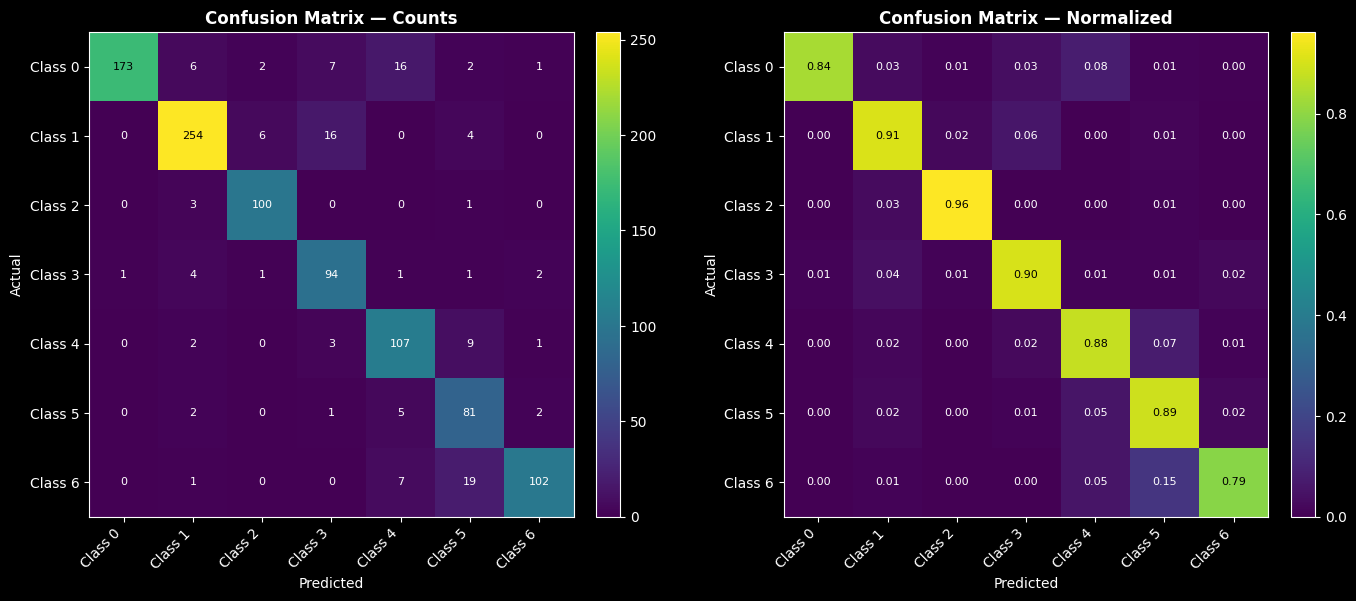

Saved figure → c:\Users\PRAYAG\Desktop\ALM\alm\outputs\figures\mad_encoder_confusion_matrix.png


In [28]:
cm = confusion_matrix(test_labels, test_preds, labels=labels_sorted)
cm_normalized = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, matrix, title, fmt in [
    (axes[0], cm, "Confusion Matrix — Counts", "d"),
    (axes[1], cm_normalized, "Confusion Matrix — Normalized", ".2f"),
]:
    im = ax.imshow(matrix, cmap="viridis")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(len(labels_sorted)))
    ax.set_yticks(range(len(labels_sorted)))
    ax.set_xticklabels(target_names, rotation=45, ha="right")
    ax.set_yticklabels(target_names)

    threshold = matrix.max() / 2.0
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix[i, j]
            text = f"{value:{fmt}}"
            color = "white" if value < threshold else "black"
            ax.text(j, i, text, ha="center", va="center", color=color, fontsize=8)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
cm_path = FIGURES_DIR / "mad_encoder_confusion_matrix.png"
fig.savefig(cm_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()
print(f"Saved figure → {cm_path}")

## 20. Embedding Sanity Check

In [29]:
_check_batch = next(iter(test_loader))
with torch.no_grad():
    _mel = _check_batch["mel"].to(device)
    _embeddings = best_model.encode(_mel)

_norms = _embeddings.norm(dim=-1)

print(f"Embedding shape : {tuple(_embeddings.shape)}")
print(f"Mean norm       : {_norms.mean().item():.4f}")
print(f"Min norm        : {_norms.min().item():.4f}")
print(f"Max norm        : {_norms.max().item():.4f}")

Embedding shape : (16, 512)
Mean norm       : 1.0000
Min norm        : 1.0000
Max norm        : 1.0000


## 21. Example Predictions

In [30]:
N_EXAMPLES = 10

example_indices = np.random.RandomState(CFG.SEED).choice(len(test_labels), size=min(N_EXAMPLES, len(test_labels)), replace=False)

print("Example Test Predictions")
print("-" * 60)
for i, idx in enumerate(example_indices, start=1):
    actual = test_labels[idx]
    predicted = test_preds[idx]
    confidence = test_probs[idx, predicted] * 100
    print(f"Sample {i:02d} | Actual: Class {actual} | Predicted: Class {predicted} | Confidence: {confidence:.2f}%")

Example Test Predictions
------------------------------------------------------------
Sample 01 | Actual: Class 1 | Predicted: Class 1 | Confidence: 99.69%
Sample 02 | Actual: Class 3 | Predicted: Class 3 | Confidence: 99.53%
Sample 03 | Actual: Class 2 | Predicted: Class 2 | Confidence: 99.48%
Sample 04 | Actual: Class 1 | Predicted: Class 1 | Confidence: 99.73%
Sample 05 | Actual: Class 0 | Predicted: Class 0 | Confidence: 99.54%
Sample 06 | Actual: Class 1 | Predicted: Class 1 | Confidence: 99.64%
Sample 07 | Actual: Class 4 | Predicted: Class 4 | Confidence: 99.29%
Sample 08 | Actual: Class 0 | Predicted: Class 0 | Confidence: 97.23%
Sample 09 | Actual: Class 1 | Predicted: Class 1 | Confidence: 99.70%
Sample 10 | Actual: Class 0 | Predicted: Class 0 | Confidence: 99.47%


## 22. Final Summary

In [31]:
summary_lines = [
    "╔══════════════════════════════════════════════════════════════╗",
    "║             MAD AUDIO ENCODER — FINAL SUMMARY                 ║",
    "╠══════════════════════════════════════════════════════════════╣",
    f"║ Dataset          : MAD".ljust(65) + "║",
    f"║ Task             : Single-label audio classification".ljust(65) + "║",
    f"║ Classes          : {CFG.NUM_CLASSES}".ljust(65) + "║",
    f"║ Sample rate      : {CFG.SAMPLE_RATE} Hz".ljust(65) + "║",
    f"║ Audio duration   : {CFG.DURATION:.0f} seconds".ljust(65) + "║",
    f"║ Mel bins         : {CFG.N_MELS}".ljust(65) + "║",
    f"║ FFT              : {CFG.N_FFT}".ljust(65) + "║",
    f"║ Hop length       : {CFG.HOP_LENGTH}".ljust(65) + "║",
    f"║ Embedding dim     : {CFG.EMBED_DIM}".ljust(65) + "║",
    f"║ Test accuracy    : {test_acc * 100:.2f}%".ljust(65) + "║",
    f"║ Macro F1         : {f1_macro:.4f}".ljust(65) + "║",
    f"║ Best checkpoint  : {BEST_MODEL_PATH.name}".ljust(65) + "║",
    "╚══════════════════════════════════════════════════════════════╝",
]
print("\n".join(summary_lines))

print("\nSaved figures:")
for path in [class_dist_path, curves_path, loss_path, acc_path, cm_path]:
    print(f"  {path}")

╔══════════════════════════════════════════════════════════════╗
║             MAD AUDIO ENCODER — FINAL SUMMARY                 ║
╠══════════════════════════════════════════════════════════════╣
║ Dataset          : MAD                                         ║
║ Task             : Single-label audio classification           ║
║ Classes          : 7                                           ║
║ Sample rate      : 16000 Hz                                    ║
║ Audio duration   : 10 seconds                                  ║
║ Mel bins         : 128                                         ║
║ FFT              : 1024                                        ║
║ Hop length       : 512                                         ║
║ Embedding dim     : 512                                        ║
║ Test accuracy    : 87.85%                                      ║
║ Macro F1         : 0.8674                                      ║
║ Best checkpoint  : alm_mad_audio_encoder_best.pth              ║
